In [99]:
import pandas as pd
import numpy as np
import scanpy as sc


In [3]:
#need to install these too
!conda install -y -c anaconda cmake 
!pip install leidenalg
!pip install louvain

Channels:
 - anaconda
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /root/miniconda3/envs/sc_env

  added / updated specs:
    - cmake


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    cmake-4.0.2                |       h74e3db0_0        19.4 MB  conda-forge
    rhash-1.4.6                |       hb9d3cd8_1         189 KB  conda-forge
    ------------------------------------------------------------
                                           Total:        19.6 MB

The following NEW packages will be INSTALLED:

  cmake              conda-forge/linux-64::cmake-4.0.2-h74e3db0_0 
  libuv              conda-forge/linux-64::libuv-1.51.0-hb9d3cd8_0 
  rhash              conda-forge/linux-64::rhash-1.4.6-hb9d3cd8_1 



cmake-4.0.2          | 19.4 MB   |                                       |   0% 
cmake-4.0.2     

In [100]:
#tutorial_sample was the dir created by cellranger based on our flag: --id tutorial_sample

adata = sc.read_csv('/mnt/c/Users/User/Documents/sc_rna_tutorial/GSM5226574_C51ctr_raw_counts.csv') 


In [101]:
adata=adata.T

In [102]:
print(adata)

AnnData object with n_obs × n_vars = 6099 × 34546


In [19]:
#Preprocessing


In [103]:
#remove cells with less than 200 gnes
sc.pp.filter_cells(adata, min_genes=200)
#remove genes that are present in less than 3 cells
sc.pp.filter_genes(adata, min_cells=10)

In [104]:
adata

AnnData object with n_obs × n_vars = 6099 × 19896
    obs: 'n_genes'
    var: 'n_cells'

In [105]:
#mark mitochondrial genes
adata.var["mt"]=adata.var_names.str.startswith("MT-")

In [106]:
#mark mitochondrial genes
adata.var[adata.var.mt==True]

,n_cells,mt
MT-ND1,1523,True
MT-ND2,1374,True
MT-CO1,1875,True
MT-CO2,1587,True
MT-ATP8,688,True
MT-ATP6,1710,True
MT-CO3,1329,True
MT-ND3,1621,True
MT-ND4L,650,True
MT-ND4,1328,True


In [9]:
adata.obs

,n_genes
TAGGTACCATGGCCAC-1_1,6764
ATTCACTGTAACAGGC-1_1,6686
TAACTTCCAACCACGC-1_1,5158
TTGGGTACACGACAAG-1_1,4900
AGGCCACAGAGTCACG-1_1,5544
...,...
CGCCATTGTTTGCCGG-1_1,355
CACTGGGGTCTACGTA-1_1,346
CATACTTGTAGAGGAA-1_1,360
TTTGGTTTCCACGGAC-1_1,299


In [ ]:
#filtering using the distribution of the data by removing outliers

In [107]:
# run qc_metric on the data
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

In [11]:
adata.obs.columns

Index(['n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt',
       'pct_counts_mt'],
      dtype='object')

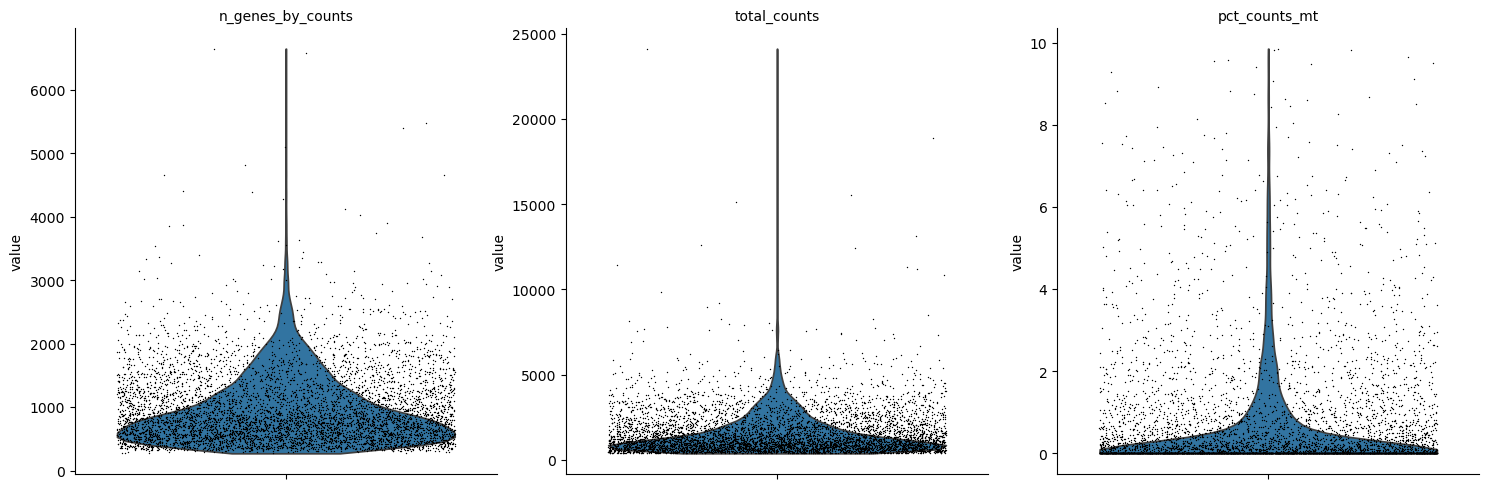

In [108]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

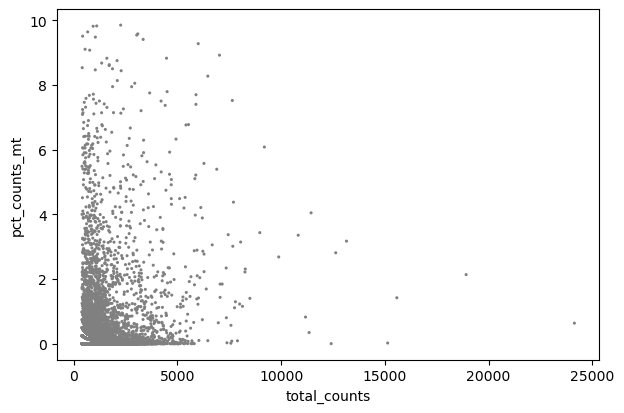

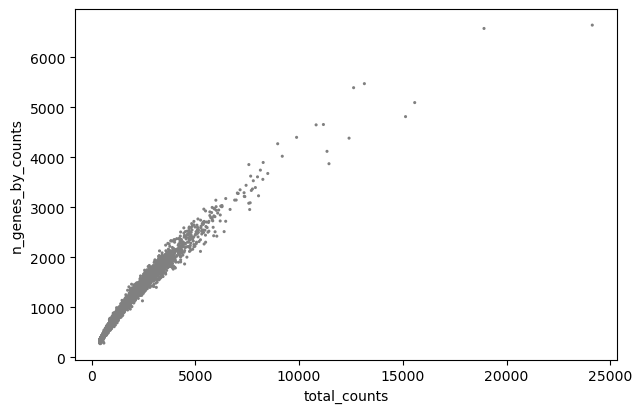

In [109]:
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

In [110]:
# set upper and lower limits
upper_lim=np.quantile(adata.obs.n_genes_by_counts.values, 0.98)
lower_lim=np.quantile(adata.obs.n_genes_by_counts.values, 0.02)

In [111]:
adata=adata[(adata.obs.n_genes_by_counts.values<upper_lim)&(adata.obs.n_genes_by_counts.values>lower_lim)]
adata=adata[adata.obs.pct_counts_mt.values<6,:]

In [113]:
#normalize to 10000 counts for each cell
sc.pp.normalize_total(adata, target_sum=1e4)
#change to log
sc.pp.log1p(adata)

In [27]:
#Clustering

In [114]:
#mark_higly variable genes
sc.pp.highly_variable_genes(adata)  #using the default values

In [115]:
adata.var[adata.var.highly_variable]

,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm
LINC01128,81,False,81,0.013773,98.671913,84.0,True,0.132094,2.599505,0.641014
SAMD11,16,False,16,0.002951,99.737662,18.0,True,0.032433,2.593750,0.612748
PLEKHN1,27,False,27,0.004591,99.557304,28.0,True,0.053183,2.725612,1.260340
AL390719.3,16,False,16,0.002623,99.737662,16.0,True,0.022608,2.571801,0.504953
TNFRSF18,15,False,15,0.002951,99.754058,18.0,True,0.030427,2.695535,1.112630
...,...,...,...,...,...,...,...,...,...,...
MT-ND5,886,True,886,0.332514,85.473028,2028.0,True,0.916818,2.563499,0.746296
MT-ND6,821,True,821,0.383178,86.538777,2337.0,True,0.866912,2.590616,0.932743
MT-CYB,1295,True,1295,0.622397,78.767011,3796.0,True,1.269031,2.598924,1.248413
BX004987.1,23,False,23,0.003771,99.622889,23.0,True,0.032397,2.572681,0.509279


In [116]:
adata.raw=adata

In [117]:
#take only highly variable genes
adata=adata[:, adata.var.highly_variable]
adata

View of AnnData object with n_obs × n_vars = 5777 × 5755
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [118]:
#regress out : is to remove unwanted variations in the data on the basis of different features. In this case total counts and pct of MT is used. it uses a linear regression b/w gene expression and features using the residuals
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])

/root/miniconda3/envs/sc_env/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:729: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [119]:
sc.pp.scale(adata, max_value=10)

In [120]:
# calculate PCAs
sc.tl.pca(adata,svd_solver="arpack")

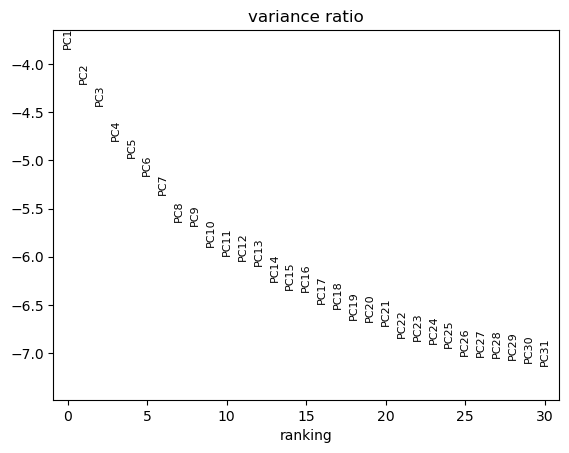

In [121]:
sc.pl.pca_variance_ratio(adata, log=True) #plotting the contribution of different components

In [122]:
sc.pp.neighbors(adata,n_neighbors=10, n_pcs=15)

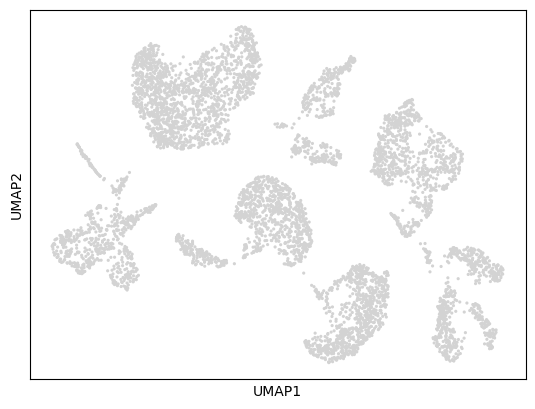

In [123]:
sc.tl.umap(adata)
sc.pl.umap(adata)

In [124]:
sc.tl.leiden(adata)
#sc.pl.umap(adata, color=["leiden"])

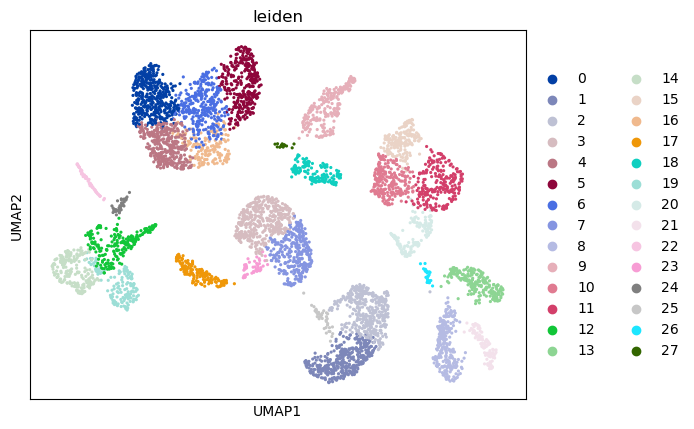

In [125]:
sc.pl.umap(adata, color=["leiden"])

/root/miniconda3/envs/sc_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:456: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/root/miniconda3/envs/sc_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/root/miniconda3/envs/sc_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: PerformanceWarning: DataF

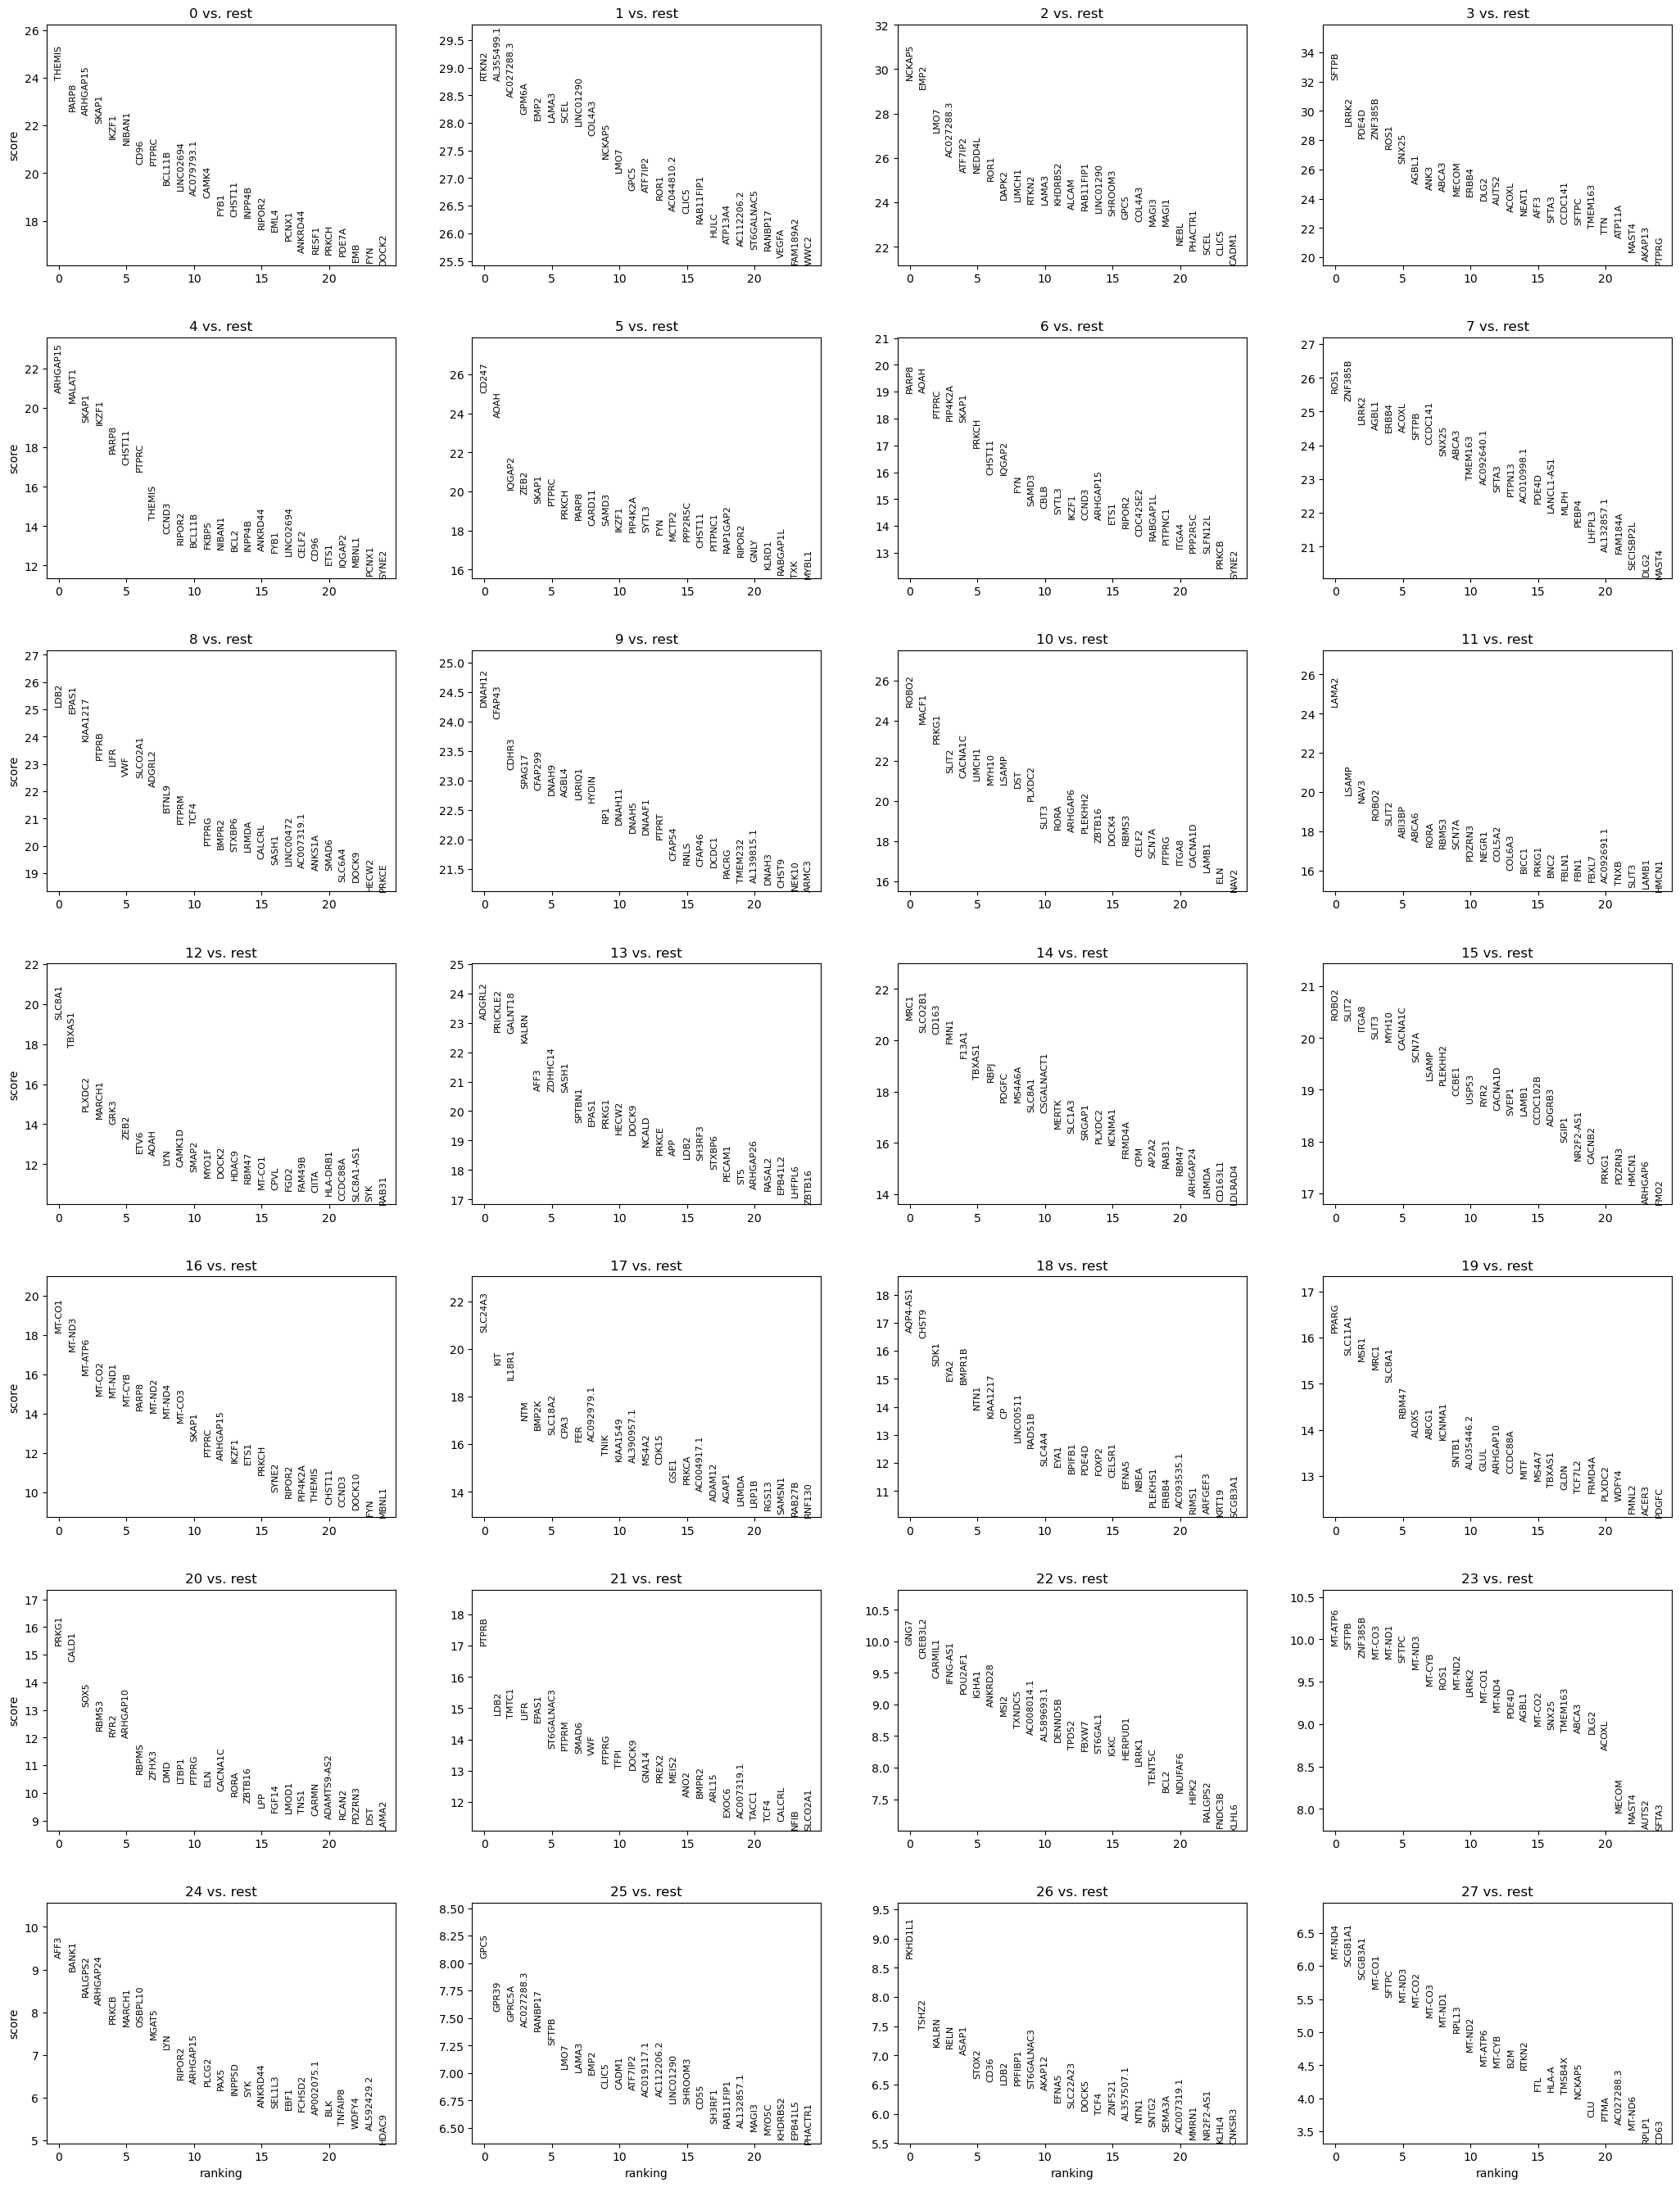

In [126]:
##Find marker genes for each cluster. 
sc.tl.rank_genes_groups(adata,"leiden",method="wilcoxon" )
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

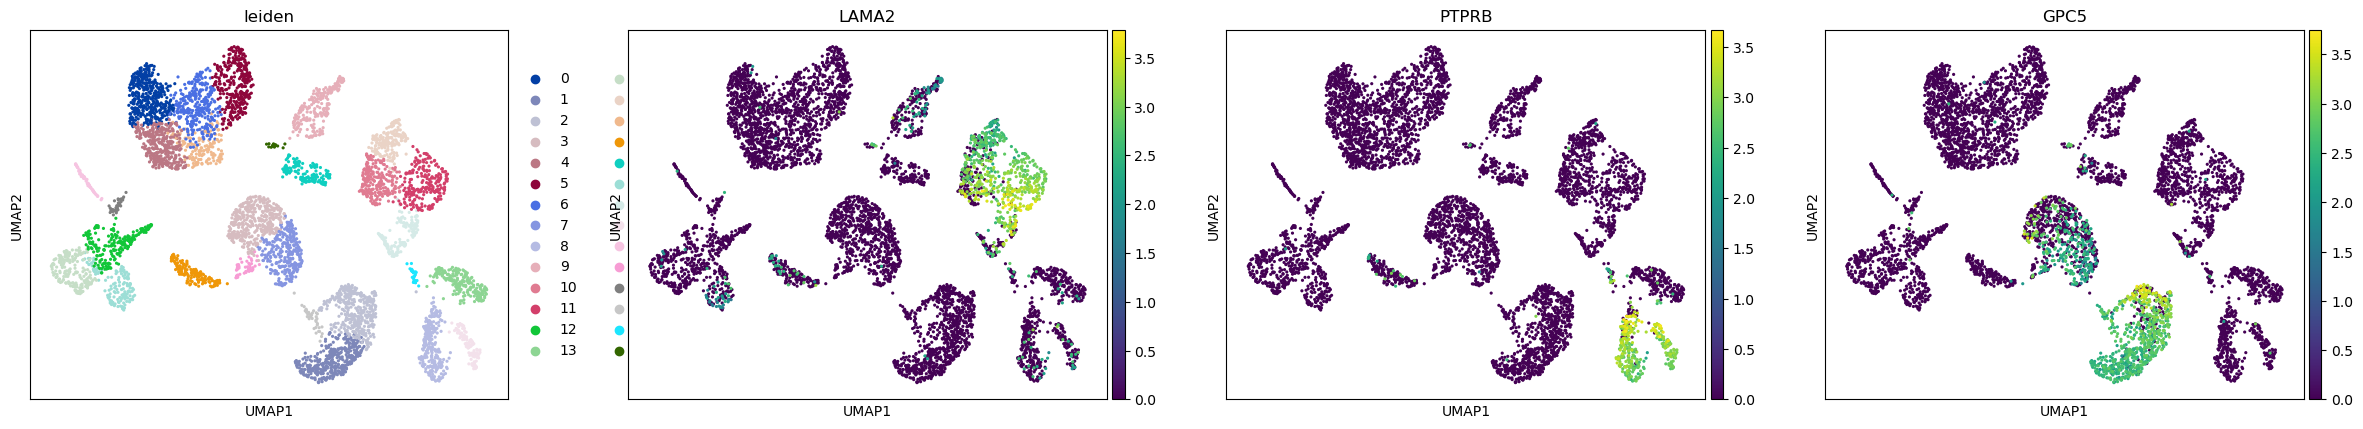

In [132]:
sc.pl.umap(adata, color=["leiden","LAMA2", "PTPRB", "GPC5"])

In [133]:
result=adata.uns["rank_genes_groups"]

In [134]:
result

{'params': {'groupby': 'leiden',
  'reference': 'rest',
  'method': 'wilcoxon',
  'use_raw': True,
  'layer': None,
  'corr_method': 'benjamini-hochberg'},
 'names': rec.array([('THEMIS', 'RTKN2', 'NCKAP5', 'SFTPB', 'ARHGAP15', 'CD247', 'PARP8', 'ROS1', 'LDB2', 'DNAH12', 'ROBO2', 'LAMA2', 'SLC8A1', 'ADGRL2', 'MRC1', 'ROBO2', 'MT-CO1', 'SLC24A3', 'AQP4-AS1', 'PPARG', 'PRKG1', 'PTPRB', 'GNG7', 'MT-ATP6', 'AFF3', 'GPC5', 'PKHD1L1', 'MT-ND4'),
            ('PARP8', 'AL355499.1', 'EMP2', 'LRRK2', 'MALAT1', 'AOAH', 'AOAH', 'ZNF385B', 'EPAS1', 'CFAP43', 'MACF1', 'LSAMP', 'TBXAS1', 'PRICKLE2', 'SLCO2B1', 'SLIT2', 'MT-ND3', 'KIT', 'CHST9', 'SLC11A1', 'CALD1', 'LDB2', 'CREB3L2', 'SFTPB', 'BANK1', 'GPR39', 'TSHZ2', 'SCGB1A1'),
            ('ARHGAP15', 'AC027288.3', 'LMO7', 'PDE4D', 'SKAP1', 'IQGAP2', 'PTPRC', 'LRRK2', 'KIAA1217', 'CDHR3', 'PRKG1', 'NAV3', 'PLXDC2', 'GALNT18', 'CD163', 'ITGA8', 'MT-ATP6', 'IL18R1', 'SDK1', 'MSR1', 'SOX5', 'TMTC1', 'CARMIL1', 'ZNF385B', 'RALGPS2', 'GPRC5A', 'KALRN'

In [129]:
out=np.array([[0,0,0,0,0]])
for i in result["names"].dtype.names:
    out=np.vstack((out, np.vstack((result["names"][i],
                                 result["scores"][i],
                                 result["pvals_adj"][i],
                                 result["logfoldchanges"][i],
                                 np.array([i]*len(result["names"][i])).astype("object"))).T))

In [135]:
out

array([[0, 0, 0, 0, 0],
       ['THEMIS', 23.912704467773438, 4.495220973718991e-122,
        4.900203227996826, '0'],
       ['PARP8', 22.601106643676758, 4.2045181626127506e-109,
        3.398223638534546, '0'],
       ...,
       ['KDM4C', -2.400285482406616, 0.9980210824248745,
        -30.225765228271484, '27'],
       ['NCOA2', -2.578907012939453, 0.9980210824248745,
        -3.5683071613311768, '27'],
       ['MALAT1', -3.191084146499634, 0.8812682993543153,
        -0.5958654284477234, '27']], shape=(557089, 5), dtype=object)

In [136]:
markers=pd.DataFrame(out, columns=["Genes", "scores", "pval_adj", "log_fc", "cluster"])

In [139]:
markers

,Genes,scores,pval_adj,log_fc,cluster
1,THEMIS,23.912704,0.0,4.900203,0
2,PARP8,22.601107,0.0,3.398224,0
3,ARHGAP15,22.42893,0.0,3.497386,0
4,SKAP1,22.097513,0.0,3.878815,0
5,IKZF1,21.461716,0.0,3.57554,0
...,...,...,...,...,...
557083,MYCBP2,-2.279627,0.998021,-3.178483,27
557084,ZNF609,-2.294627,0.998021,-3.29467,27
557085,KMT2C,-2.329143,0.998021,-2.190228,27
557086,KDM4C,-2.400285,0.998021,-30.225765,27


In [144]:
markers=markers[(abs(markers.log_fc>1)) &(markers.pval_adj<0.05)]

In [146]:
#look at specific clusters
markers[markers.cluster=="11"]

,Genes,scores,pval_adj,log_fc,cluster
218857,LAMA2,24.396101,0.0,6.033931,11
218858,LSAMP,19.878038,0.0,5.091924,11
218859,NAV3,19.494635,0.0,5.461159,11
218860,ROBO2,18.610258,0.0,4.956147,11
218861,SLIT2,18.321228,0.0,4.603176,11
...,...,...,...,...,...
219422,FLG-AS1,3.149409,0.035496,2.868743,11
219427,RAI2,3.130217,0.037531,2.849464,11
219437,BRINP3,3.056737,0.047011,4.874688,11
219439,LUM,3.044219,0.048703,4.774124,11


In [150]:
# look at cells positive for a specific gene e.g. "LAMA2"
lama2_index=np.where(adata.raw.var_names=="LAMA2")[0][0]
lama2=adata.raw.X[:,lama2_index]
adata.obs["lama2"]=lama2
adata.obs[adata.obs.lama2>0]

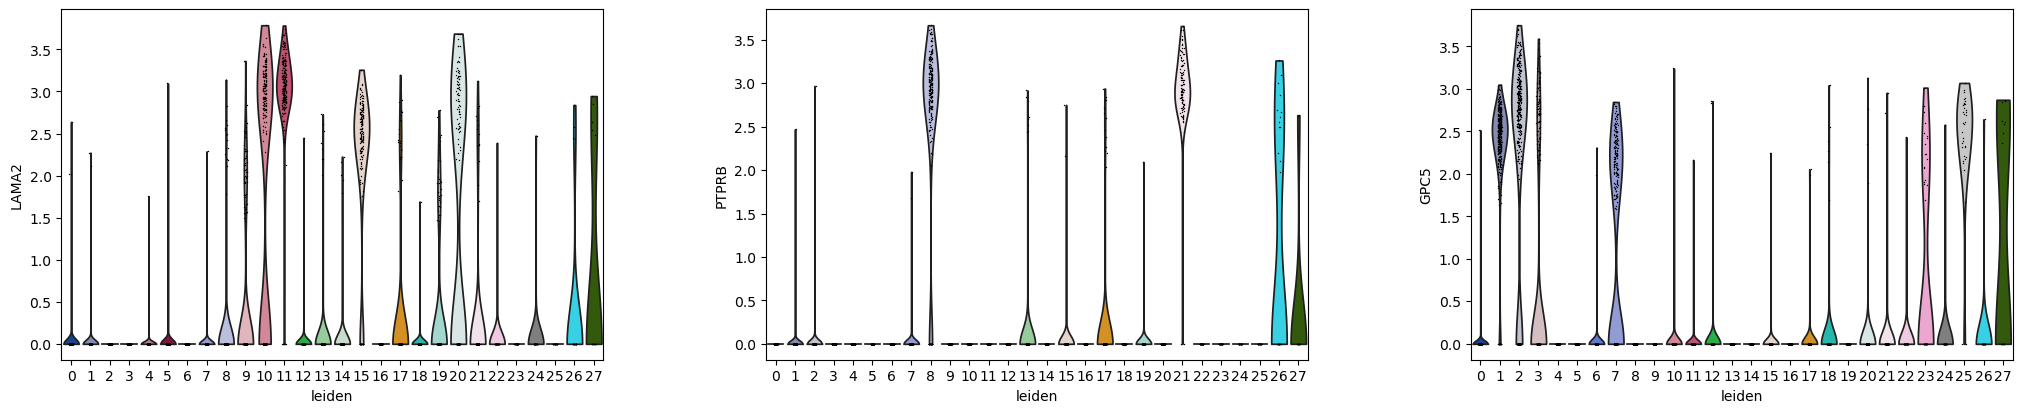

In [164]:
sc.pl.violin(adata,["LAMA2", "PTPRB", "GPC5"], groupby="leiden")